In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os, glob
from scipy.ndimage import gaussian_filter1d


In [17]:
raw_spikes_df = pd.read_parquet('../data/bin/spikes/raw_spikes.parquet')
raw_spikes_df

,subj,sess,hemi,region,neur_id,base_start,base_stop,enc_spikes,base_spikes
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744...","[480.504041, 480.822666, 481.2748535, 481.3912..."
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,...","[484.50519625, 484.55057125, 486.2016015, 486...."
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707...","[488.7439755, 489.63731925]"
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ...","[478.920417, 478.9386045, 479.02932325, 479.03..."
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175...","[480.52132225, 481.14500975, 481.2111035, 481...."
...,...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325...","[479.55532375, 479.90207375, 479.90851125, 481..."
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0...","[478.9684175, 479.19073, 481.5164165, 482.3733..."
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087...","[483.2832905, 484.68175925, 484.84519675, 486...."
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1...","[480.00151025, 486.47719575, 486.615352, 488.3..."


In [21]:
def compute_fr_stats(row):
    # Encoding period
    enc_bins = np.arange(0, row['base_start'], 1)
    enc_counts, _ = np.histogram(row['enc_spikes'], bins=enc_bins)
    enc_fr = enc_counts  # spikes per 1s bin
    avg_enc_FR = np.mean(enc_fr) if len(enc_fr) > 0 else np.nan
    sd_enc_FR = np.std(enc_fr) if len(enc_fr) > 0 else np.nan

    # Baseline period
    base_bins = np.arange(row['base_start'], row['base_stop'], 1)
    base_counts, _ = np.histogram(row['base_spikes'], bins=base_bins)
    base_fr = base_counts
    avg_base_FR = np.mean(base_fr) if len(base_fr) > 0 else np.nan
    sd_base_FR = np.std(base_fr) if len(base_fr) > 0 else np.nan

    return pd.Series([avg_enc_FR, sd_enc_FR, avg_base_FR, sd_base_FR],
                     index=['avg_enc_FR', 'sd_enc_FR', 'avg_base_FR', 'sd_base_FR'])

raw_spikes_df[['avg_enc_FR', 'sd_enc_FR', 'avg_base_FR', 'sd_base_FR']] = raw_spikes_df.apply(compute_fr_stats, axis=1)


In [24]:
raw_spikes_df

,subj,sess,hemi,region,neur_id,base_start,base_stop,enc_spikes,base_spikes,avg_enc_FR,sd_enc_FR,avg_base_FR,sd_base_FR
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744...","[480.504041, 480.822666, 481.2748535, 481.3912...",0.453975,1.658304,1.192308,1.961538
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,...","[484.50519625, 484.55057125, 486.2016015, 486....",0.437238,0.817713,0.673077,1.069169
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707...","[488.7439755, 489.63731925]",0.169456,0.562559,0.038462,0.192308
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ...","[478.920417, 478.9386045, 479.02932325, 479.03...",17.234310,8.709125,12.269231,5.288287
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175...","[480.52132225, 481.14500975, 481.2111035, 481....",1.456067,1.462629,1.673077,1.410417
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325...","[479.55532375, 479.90207375, 479.90851125, 481...",2.376569,2.020925,2.865385,2.645961
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0...","[478.9684175, 479.19073, 481.5164165, 482.3733...",5.150628,2.901866,3.461538,3.870309
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087...","[483.2832905, 484.68175925, 484.84519675, 486....",0.956067,1.300207,1.461538,1.549957
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1...","[480.00151025, 486.47719575, 486.615352, 488.3...",1.089958,1.098812,0.788462,1.043967


In [25]:
# print rows with any nan
nan_rows = raw_spikes_df[raw_spikes_df.isna().any(axis=1)]
if not nan_rows.empty:
    print("Rows with NaN values:")
    print(nan_rows)
else:
    print("No NaN values found in the DataFrame.")

No NaN values found in the DataFrame.


In [23]:
# for each of the 4 FR stats, print how many are 0
for col in ['avg_enc_FR', 'sd_enc_FR', 'avg_base_FR', 'sd_base_FR']:
    num_zeros = (raw_spikes_df[col] == 0).sum()
    print(f"{col}: {num_zeros} zeros")

avg_enc_FR: 7 zeros
sd_enc_FR: 7 zeros
avg_base_FR: 16 zeros
sd_base_FR: 16 zeros


In [20]:
# print number of rows where there are no enc_spikes
print("Number of rows where len(base_spikes) < 2:", len(raw_spikes_df[raw_spikes_df['enc_spikes'].apply(len) < 1]))

Number of rows where len(base_spikes) < 2: 7


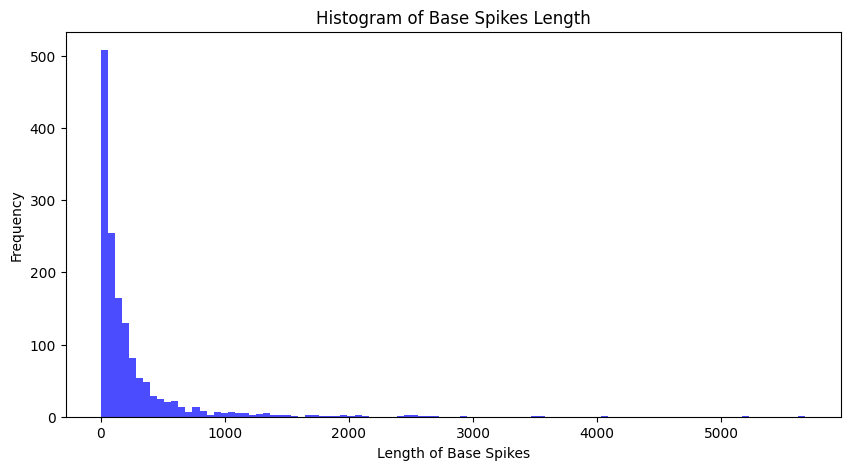

In [8]:
# plot hist of len(raw_spikes_df[base_spikes])
plt.figure(figsize=(10, 5))
plt.hist(raw_spikes_df['base_spikes'].apply(len), bins=100, color='blue', alpha=0.7)
plt.title('Histogram of Base Spikes Length')
plt.xlabel('Length of Base Spikes')
plt.ylabel('Frequency')
plt.show()

In [9]:
# print number of rows where len(base_spikes) < 2
print("Number of rows where len(base_spikes) < 2:", len(raw_spikes_df[raw_spikes_df['base_spikes'].apply(len) < 2]))

Number of rows where len(base_spikes) < 2: 29


In [10]:
# print number of rows where any val in np.diff(enc_spikes) > 16
print("Number of rows where any value in np.diff(enc_spikes) > 16:", len(raw_spikes_df[raw_spikes_df['enc_spikes'].apply(lambda x: np.any(np.diff(x) > 16))]))

Number of rows where any value in np.diff(enc_spikes) > 16: 413


In [11]:
# print overlapping rows from the conditions above
overlapping_rows = raw_spikes_df[(raw_spikes_df['base_spikes'].apply(len) < 2) & 
                                  (raw_spikes_df['enc_spikes'].apply(lambda x: np.any(np.diff(x) > 16)))]
print("Overlapping rows where len(base_spikes) < 2 and any value in np.diff(enc_spikes) > 16:", len(overlapping_rows))

Overlapping rows where len(base_spikes) < 2 and any value in np.diff(enc_spikes) > 16: 23


In [ ]:
# create cols avg_enc_FR and avg_base_FR

In [16]:
# # retain df where len(base_spikes) >= 2
# raw_spikes_df = raw_spikes_df[raw_spikes_df['base_spikes'].apply(len) >= 2]

# retain df where any value in np.diff(enc_spikes) <= 16
spikes_df = raw_spikes_df[~raw_spikes_df['enc_spikes'].apply(lambda x: np.any(np.diff(x) > 16))]
print(len(spikes_df))   

1044


In [13]:
def preprocess_spikes(spikes_df, bin_dur):

    # ends of encoding & baseline
    enc_stop, base_stop = spikes_df['base_start'][0], spikes_df['base_stop'][0]
    
    # binning
    enc_bin_edges = np.arange(0, enc_stop + bin_dur, bin_dur)
    base_bin_edges = np.arange(enc_stop, base_stop + bin_dur, bin_dur)

    # init
    time_by_rates = np.zeros((len(enc_bin_edges)-1, len(spikes_df)))

    col_names = []

    for idx, neur in spikes_df.iterrows():

        col_name = neur['hemi'] + '_' + neur['region'] + '_' + neur['neur_id']
        col_names.append(col_name)

        # get enc rates per bin
        enc_spike_counts, _ = np.histogram(neur['enc_spikes'], bins=enc_bin_edges)
        enc_rates = enc_spike_counts / bin_dur

        # get base rates per bin
        base_spike_counts, _ = np.histogram(neur['base_spikes'], bins=base_bin_edges)
        base_rates = base_spike_counts / bin_dur

        # norm
        base_mean, base_sd = np.mean(base_rates), np.std(base_rates)
        enc_rate_normed = (enc_rates - base_mean)# / (base_sd + .01)

        # smoothing
        enc_rate_smoothed = gaussian_filter1d(enc_rate_normed, sigma=1)

        # save
        time_by_rates[:, idx] = enc_rate_smoothed

    time_axis = np.arange(0, len(enc_bin_edges)-1) * bin_dur
    
    return pd.DataFrame(time_by_rates, columns=col_names, index=time_axis)

t_by_N = preprocess_spikes(raw_spikes_df, bin_dur=1)
t_by_N


,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0,-1.169811,-0.660377,-0.037736,-7.245837,0.334487,0.302214,-0.471430,1.074411,1.015224,1.016478,...,-0.09434,0.0,-0.731453,-1.052038,-0.094340,-0.229132,5.781638,-1.433962,-0.710462,-0.388810
1,-1.169811,-0.660377,-0.037736,-5.104755,-0.368411,0.638436,-0.462834,1.388186,1.646839,1.666912,...,-0.09434,0.0,0.133235,-1.002613,-0.094340,0.084678,3.984333,-1.433962,-0.473057,-0.648495
2,-1.169811,-0.660377,-0.037736,1.927417,-0.359983,0.772425,-0.363582,1.468620,1.825822,1.871781,...,-0.09434,0.0,0.680155,-0.814231,-0.094340,0.142263,3.192274,-1.433962,-0.078679,-0.456048
3,-1.169677,-0.660377,-0.037736,9.005689,-0.198881,0.396465,0.016677,0.859685,1.288324,1.640503,...,-0.09434,0.0,-0.441062,-0.643562,-0.094340,0.126043,2.553489,-1.433962,0.109435,0.041578
4,-1.165379,-0.660244,-0.037602,9.588475,-0.767255,-0.150855,0.380180,0.684465,0.606579,1.535459,...,-0.09434,0.0,-1.281979,-0.625800,-0.094340,-0.122944,2.049218,-1.433962,-0.074247,0.727586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,-1.169811,-0.498136,0.020687,0.298381,-0.517391,0.561779,-0.068055,-0.037602,-0.101622,-0.405328,...,-0.09434,0.0,0.464104,-0.535679,-0.089908,-1.121551,2.563051,0.157527,0.275974,1.081316
475,-1.169811,0.070103,0.258227,-0.006664,-0.503004,0.513712,-0.171170,-0.033170,0.297321,-0.486030,...,-0.09434,0.0,0.523484,-0.634931,-0.040348,0.097122,0.795649,0.018972,0.571100,0.988559
476,-1.169811,0.594876,0.603313,0.849377,-0.759060,0.674278,-0.117179,0.020687,0.646705,-0.696859,...,-0.09434,0.0,-0.158127,-0.168483,0.147766,0.330363,-0.453108,-0.294838,0.405666,0.951457
477,-1.169811,0.361901,0.607745,3.071834,-0.552529,0.804272,0.232072,0.258227,0.539560,-0.889271,...,-0.09434,0.0,-0.579348,-0.007614,0.309036,-0.538658,-1.226113,-0.214269,-0.015690,1.010837
